📊 DATOS CARGADOS
Registros: 263
Columnas: 31
Periodo: 2017-12-31 a 2025-12-13

🔍 INFO DEL DATASET:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 31 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   Fecha                   263 non-null    datetime64[ns]
 1   Año                     263 non-null    int64         
 2   mes                     263 non-null    int64         
 3   trimestre               263 non-null    int64         
 4   nombre_mes              263 non-null    object        
 5   dia_semana              263 non-null    int64         
 6   nombre_dia              263 non-null    object        
 7   semana_año              263 non-null    int64         
 8   periodo_mes             263 non-null    object        
 9   estacion                263 non-null    object        
 10  es_fin_semana           263 non-null    bool          
 11  Kilometros 

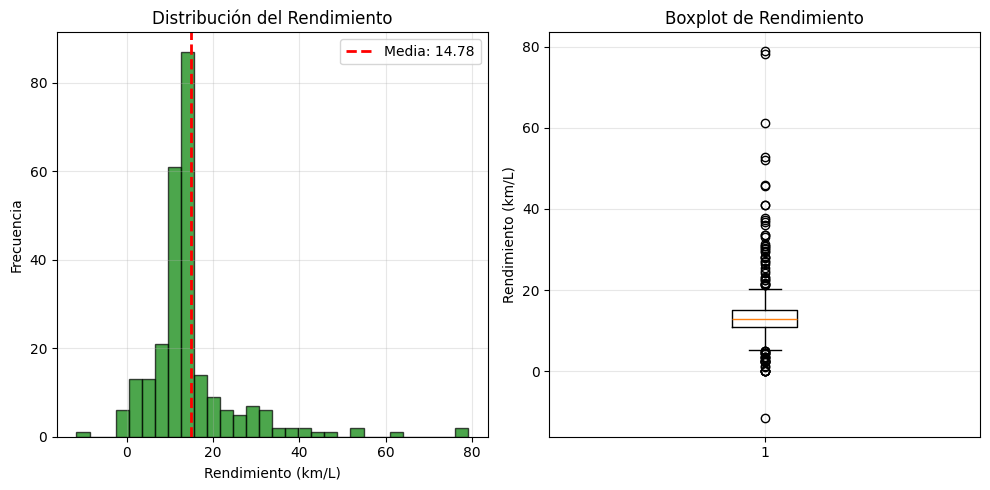


✅ Exploración inicial completada


In [ ]:
# ==========================================
# MODELO ML - PREDICCIÓN DE RENDIMIENTO
# ==========================================
# Objetivo: Predecir el rendimiento del vehículo (km/L)
# basado en variables contextuales y de uso

# 1. SETUP
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# 2. CARGA DE DATOS
df = pd.read_csv('gasolina_dataset_completo.csv', parse_dates=['Fecha'])

print("📊 DATOS CARGADOS")
print("="*70)
print(f"Registros: {len(df)}")
print(f"Columnas: {len(df.columns)}")
print(f"Periodo: {df['Fecha'].min().date()} a {df['Fecha'].max().date()}")

# Información del dataset
print(f"\n🔍 INFO DEL DATASET:")
df.info()

# Estadísticas descriptivas de la variable objetivo
print(f"\n📈 ESTADÍSTICAS DE RENDIMIENTO (Variable Objetivo):")
print(df['rendimiento_kml'].describe())

# Distribución del rendimiento
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.hist(df['rendimiento_kml'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='green')
plt.axvline(df['rendimiento_kml'].mean(), color='red', linestyle='--', linewidth=2,
            label=f'Media: {df["rendimiento_kml"].mean():.2f}')
plt.xlabel('Rendimiento (km/L)')
plt.ylabel('Frecuencia')
plt.title('Distribución del Rendimiento')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.boxplot(df['rendimiento_kml'].dropna())
plt.ylabel('Rendimiento (km/L)')
plt.title('Boxplot de Rendimiento')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\n✅ Exploración inicial completada")

In [ ]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

print("\n🔧 FEATURE ENGINEERING PARA ML")
print("="*70)

# Crear copia para manipular
df_ml = df.copy()

# 1. Eliminar primera fila (no tiene km_recorridos)
df_ml = df_ml[df_ml['km_recorridos'].notna()].copy()

# 2. Eliminar outliers extremos (opcional, según tu análisis)
# Puedes decidir si incluirlos o no
# df_ml = df_ml[df_ml['es_outlier'] == False].copy()

# 3. Variables temporales adicionales
df_ml['año'] = df_ml['Fecha'].dt.year
df_ml['trimestre'] = df_ml['Fecha'].dt.quarter
df_ml['dia_mes'] = df_ml['Fecha'].dt.day

# 4. Variable de tendencia temporal (contador secuencial)
df_ml = df_ml.sort_values('Fecha').reset_index(drop=True)
df_ml['tendencia'] = range(len(df_ml))

# 5. Promedio móvil de rendimiento (últimas 5 recargas)
df_ml['rendimiento_ma5'] = df_ml['rendimiento_kml'].rolling(window=5, min_periods=1).mean()

# 6. Diferencia de precio respecto a la recarga anterior
df_ml['precio_diff'] = df_ml['Precio'].diff()

# 7. Encoding de variables categóricas
# Estación del año
le_estacion = LabelEncoder()
df_ml['estacion_encoded'] = le_estacion.fit_transform(df_ml['estacion'])

# Tipo de recarga
le_tipo_recarga = LabelEncoder()
df_ml['tipo_recarga_encoded'] = le_tipo_recarga.fit_transform(df_ml['tipo_recarga'])

# Día de la semana (ya viene como número 0-6)
# Fin de semana (ya viene como True/False, convertir a 0/1)
df_ml['fin_semana_num'] = df_ml['es_fin_semana'].astype(int)

# 8. Variable de kilometraje acumulado (desgaste del vehículo)
df_ml['km_acumulados_norm'] = (df_ml['km_acumulados'] - df_ml['km_acumulados'].min()) / \
                               (df_ml['km_acumulados'].max() - df_ml['km_acumulados'].min())

print(f"✅ Features creadas")
print(f"📊 Total de columnas ahora: {len(df_ml.columns)}")

# Mostrar las nuevas features
nuevas_features = ['año', 'trimestre', 'dia_mes', 'tendencia', 'rendimiento_ma5',
                   'precio_diff', 'estacion_encoded', 'tipo_recarga_encoded',
                   'fin_semana_num', 'km_acumulados_norm']
print(f"\n🆕 Nuevas features creadas:")
for feature in nuevas_features:
    print(f"   - {feature}")


🔧 FEATURE ENGINEERING PARA ML
✅ Features creadas
📊 Total de columnas ahora: 40

🆕 Nuevas features creadas:
   - año
   - trimestre
   - dia_mes
   - tendencia
   - rendimiento_ma5
   - precio_diff
   - estacion_encoded
   - tipo_recarga_encoded
   - fin_semana_num
   - km_acumulados_norm



📋 SELECCIÓN DE FEATURES PARA EL MODELO
📊 Registros disponibles para ML: 261
🎯 Variable objetivo: rendimiento_kml
📈 Features seleccionadas: 14

🔍 CORRELACIÓN DE FEATURES CON LA VARIABLE OBJETIVO:
km_recorridos           0.487596
dias_entre_recargas     0.447543
rendimiento_ma5         0.423275
precio_diff             0.318130
Precio                  0.197960
km_acumulados_norm      0.133419
tendencia               0.125912
estacion_encoded        0.073026
trimestre              -0.008732
mes                    -0.019243
dia_semana             -0.068082
fin_semana_num         -0.086547
tipo_recarga_encoded   -0.092523
Litros                 -0.569109
dtype: float64


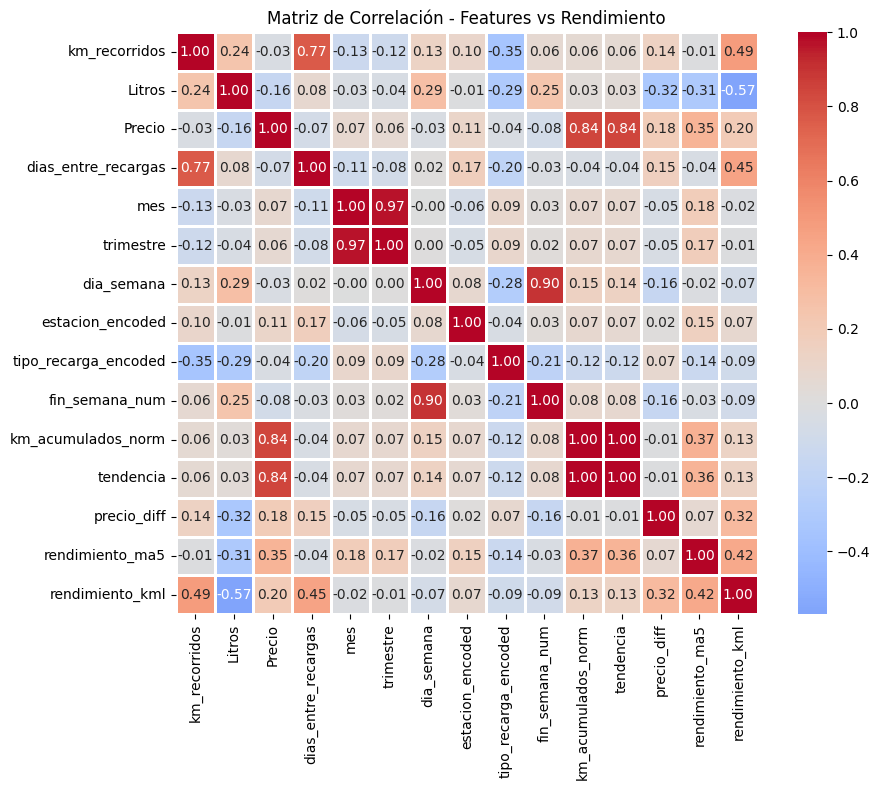


📊 DIVISIÓN DE DATOS:
   Training set: 208 registros (79.7%)
   Test set: 53 registros (20.3%)

✅ Datos preparados para entrenamiento


In [ ]:
# ==========================================
# SELECCIÓN DE FEATURES Y PREPARACIÓN
# ==========================================

print("\n📋 SELECCIÓN DE FEATURES PARA EL MODELO")
print("="*70)

# Variable objetivo
target = 'rendimiento_kml'

# Features candidatas (variables predictoras)
feature_candidates = [
    'km_recorridos',
    'Litros',
    'Precio',
    'dias_entre_recargas',
    'mes',
    'trimestre',
    'dia_semana',
    'estacion_encoded',
    'tipo_recarga_encoded',
    'fin_semana_num',
    'km_acumulados_norm',
    'tendencia',
    'precio_diff',
    'rendimiento_ma5'
]

# Crear dataset limpio para ML (sin NaN)
df_clean = df_ml[feature_candidates + [target]].dropna().copy()

print(f"📊 Registros disponibles para ML: {len(df_clean)}")
print(f"🎯 Variable objetivo: {target}")
print(f"📈 Features seleccionadas: {len(feature_candidates)}")

# Separar X (features) y y (target)
X = df_clean[feature_candidates]
y = df_clean[target]

# Análisis de correlación
print(f"\n🔍 CORRELACIÓN DE FEATURES CON LA VARIABLE OBJETIVO:")
correlaciones = X.corrwith(y).sort_values(ascending=False)
print(correlaciones)

# Visualización de correlaciones
plt.figure(figsize=(10, 8))
correlation_matrix = df_clean[feature_candidates + [target]].corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, square=True, linewidths=1)
plt.title('Matriz de Correlación - Features vs Rendimiento')
plt.tight_layout()
plt.show()

# Train/Test Split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\n📊 DIVISIÓN DE DATOS:")
print(f"   Training set: {len(X_train)} registros ({len(X_train)/len(X)*100:.1f}%)")
print(f"   Test set: {len(X_test)} registros ({len(X_test)/len(X)*100:.1f}%)")

# Scaling de features (opcional, mejora algunos modelos)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n✅ Datos preparados para entrenamiento")

In [ ]:
# ==========================================
# ENTRENAMIENTO DE MODELOS
# ==========================================

print("\n🤖 ENTRENAMIENTO DE MODELOS")
print("="*70)
# Diccionario para almacenar resultados
resultados = {}

# ===== MODELO 1: LINEAR REGRESSION (Baseline) =====
print("\n📐 Modelo 1: Linear Regression (Baseline)")
lr = LinearRegression()
lr.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr.predict(X_test)

# Métricas
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

resultados['Linear Regression'] = {
    'modelo': lr,
    'mae': mae_lr,
    'rmse': rmse_lr,
    'r2': r2_lr,
    'predicciones': y_pred_lr
}

print(f"   MAE: {mae_lr:.3f} km/L")
print(f"   RMSE: {rmse_lr:.3f} km/L")
print(f"   R²: {r2_lr:.3f}")

# ===== MODELO 2: RANDOM FOREST REGRESSOR =====
print("\n🌳 Modelo 2: Random Forest Regressor")
rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

resultados['Random Forest'] = {
    'modelo': rf,
    'mae': mae_rf,
    'rmse': rmse_rf,
    'r2': r2_rf,
    'predicciones': y_pred_rf
}

print(f"   MAE: {mae_rf:.3f} km/L")
print(f"   RMSE: {rmse_rf:.3f} km/L")
print(f"   R²: {r2_rf:.3f}")

# ===== MODELO 3: GRADIENT BOOSTING REGRESSOR =====
print("\n🚀 Modelo 3: Gradient Boosting Regressor")
gb = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    random_state=42
)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

mae_gb = mean_absolute_error(y_test, y_pred_gb)
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
r2_gb = r2_score(y_test, y_pred_gb)

resultados['Gradient Boosting'] = {
    'modelo': gb,
    'mae': mae_gb,
    'rmse': rmse_gb,
    'r2': r2_gb,
    'predicciones': y_pred_gb
}

print(f"   MAE: {mae_gb:.3f} km/L")
print(f"   RMSE: {rmse_gb:.3f} km/L")
print(f"   R²: {r2_gb:.3f}")

print(f"\n✅ Modelos entrenados")



🤖 ENTRENAMIENTO DE MODELOS

📐 Modelo 1: Linear Regression (Baseline)
   MAE: 3.158 km/L
   RMSE: 5.749 km/L
   R²: 0.752

🌳 Modelo 2: Random Forest Regressor
   MAE: 2.392 km/L
   RMSE: 6.645 km/L
   R²: 0.668

🚀 Modelo 3: Gradient Boosting Regressor
   MAE: 2.034 km/L
   RMSE: 5.915 km/L
   R²: 0.737

✅ Modelos entrenados



📊 COMPARACIÓN DE MODELOS
              Modelo       MAE      RMSE        R²
0  Linear Regression  3.158243  5.748530  0.751880
1  Gradient Boosting  2.034371  5.914944  0.737307
2      Random Forest  2.392476  6.645440  0.668415


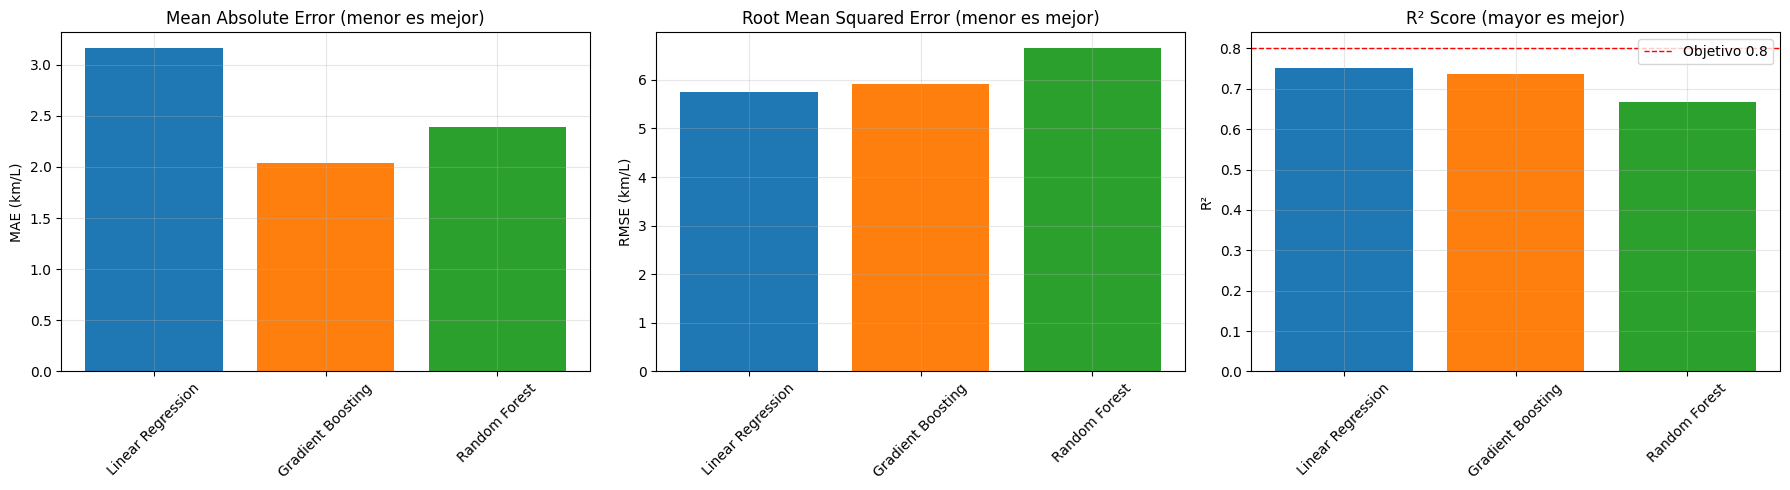


🏆 MEJOR MODELO: Linear Regression
   R² = 0.752
   MAE = 3.158 km/L
   RMSE = 5.749 km/L


In [ ]:
# ==========================================
# COMPARACIÓN DE MODELOS
# ==========================================

print("\n📊 COMPARACIÓN DE MODELOS")
print("="*70)

# Crear DataFrame de comparación
comparacion = pd.DataFrame({
    'Modelo': list(resultados.keys()),
    'MAE': [resultados[m]['mae'] for m in resultados],
    'RMSE': [resultados[m]['rmse'] for m in resultados],
    'R²': [resultados[m]['r2'] for m in resultados]
})

comparacion = comparacion.sort_values('R²', ascending=False).reset_index(drop=True)
print(comparacion)

# Visualización comparativa
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# MAE
axes[0].bar(comparacion['Modelo'], comparacion['MAE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[0].set_ylabel('MAE (km/L)')
axes[0].set_title('Mean Absolute Error (menor es mejor)')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, alpha=0.3)

# RMSE
axes[1].bar(comparacion['Modelo'], comparacion['RMSE'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[1].set_ylabel('RMSE (km/L)')
axes[1].set_title('Root Mean Squared Error (menor es mejor)')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, alpha=0.3)

# R²
axes[2].bar(comparacion['Modelo'], comparacion['R²'], color=['#1f77b4', '#ff7f0e', '#2ca02c'])
axes[2].set_ylabel('R²')
axes[2].set_title('R² Score (mayor es mejor)')
axes[2].tick_params(axis='x', rotation=45)
axes[2].axhline(y=0.8, color='red', linestyle='--', linewidth=1, label='Objetivo 0.8')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Seleccionar el mejor modelo
mejor_modelo_nombre = comparacion.iloc[0]['Modelo']
mejor_modelo = resultados[mejor_modelo_nombre]['modelo']

print(f"\n🏆 MEJOR MODELO: {mejor_modelo_nombre}")
print(f"   R² = {comparacion.iloc[0]['R²']:.3f}")
print(f"   MAE = {comparacion.iloc[0]['MAE']:.3f} km/L")
print(f"   RMSE = {comparacion.iloc[0]['RMSE']:.3f} km/L")



🔍 IMPORTANCIA DE FEATURES

📊 COEFICIENTES DE REGRESIÓN LINEAL:
                 Feature  Coeficiente
10    km_acumulados_norm    -7.977892
1                 Litros    -0.896828
13       rendimiento_ma5     0.600409
2                 Precio     0.497056
9         fin_semana_num     0.431799
8   tipo_recarga_encoded    -0.364917
5              trimestre    -0.264849
6             dia_semana     0.219513
7       estacion_encoded    -0.218566
3    dias_entre_recargas     0.167585
12           precio_diff     0.080749
0          km_recorridos     0.048937
11             tendencia     0.027199
4                    mes     0.006985


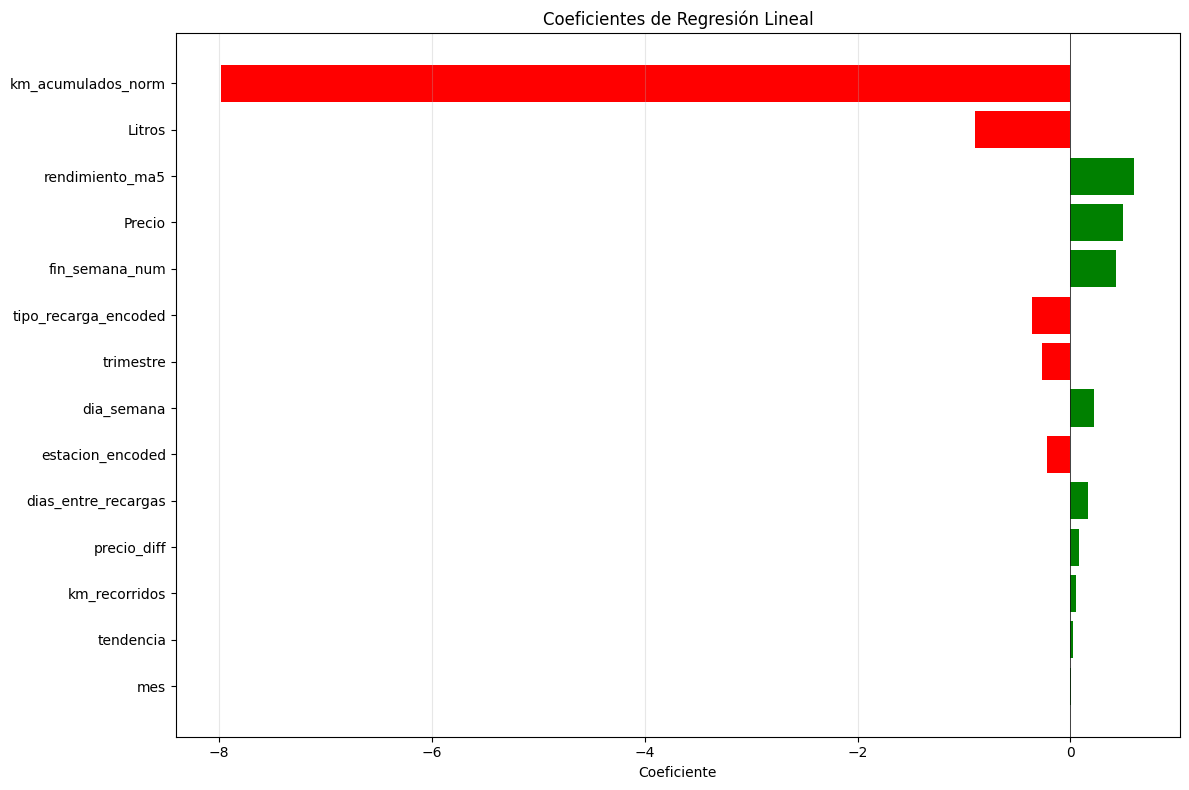


✅ Análisis de importancia completado


In [ ]:
# ==========================================
# FEATURE IMPORTANCE
# ==========================================

print("\n🔍 IMPORTANCIA DE FEATURES")
print("="*70)

# Obtener importancia de features del mejor modelo
# (Funciona para Random Forest y Gradient Boosting, no para Linear Regression)

if mejor_modelo_nombre in ['Random Forest', 'Gradient Boosting']:
    # Obtener importancias
    importances = mejor_modelo.feature_importances_

    # Crear DataFrame
    feature_importance_df = pd.DataFrame({
        'Feature': feature_candidates,
        'Importance': importances
    }).sort_values('Importance', ascending=False)

    print(f"\n📊 TOP 10 FEATURES MÁS IMPORTANTES:")
    print(feature_importance_df.head(10))

    # Visualización
    plt.figure(figsize=(12, 8))

    # Top 15 features
    top_n = 15
    top_features = feature_importance_df.head(top_n)

    plt.barh(range(len(top_features)), top_features['Importance'], color='steelblue')
    plt.yticks(range(len(top_features)), top_features['Feature'])
    plt.xlabel('Importancia')
    plt.title(f'Top {top_n} Features Más Importantes - {mejor_modelo_nombre}')
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

    # Interpretación
    print(f"\n💡 INTERPRETACIÓN:")
    print(f"   Las variables más influyentes en el rendimiento son:")
    for i, row in feature_importance_df.head(5).iterrows():
        print(f"   {i+1}. {row['Feature']}: {row['Importance']:.3f}")

elif mejor_modelo_nombre == 'Linear Regression':
    # Para regresión lineal, mostrar coeficientes
    coeficientes = pd.DataFrame({
        'Feature': feature_candidates,
        'Coeficiente': mejor_modelo.coef_
    }).sort_values('Coeficiente', key=abs, ascending=False)

    print(f"\n📊 COEFICIENTES DE REGRESIÓN LINEAL:")
    print(coeficientes)

    # Visualización
    plt.figure(figsize=(12, 8))
    plt.barh(range(len(coeficientes)), coeficientes['Coeficiente'],
             color=['green' if x > 0 else 'red' for x in coeficientes['Coeficiente']])
    plt.yticks(range(len(coeficientes)), coeficientes['Feature'])
    plt.xlabel('Coeficiente')
    plt.title('Coeficientes de Regresión Lineal')
    plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    plt.gca().invert_yaxis()
    plt.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()

print(f"\n✅ Análisis de importancia completado")


📈 VISUALIZACIÓN DE PREDICCIONES


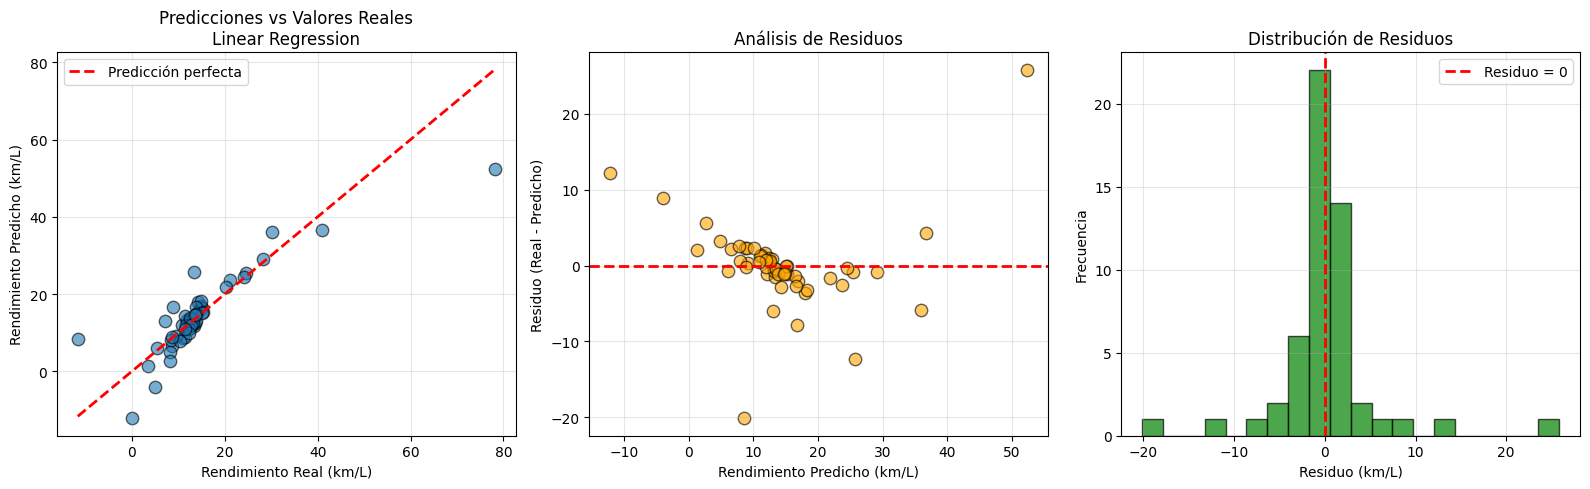

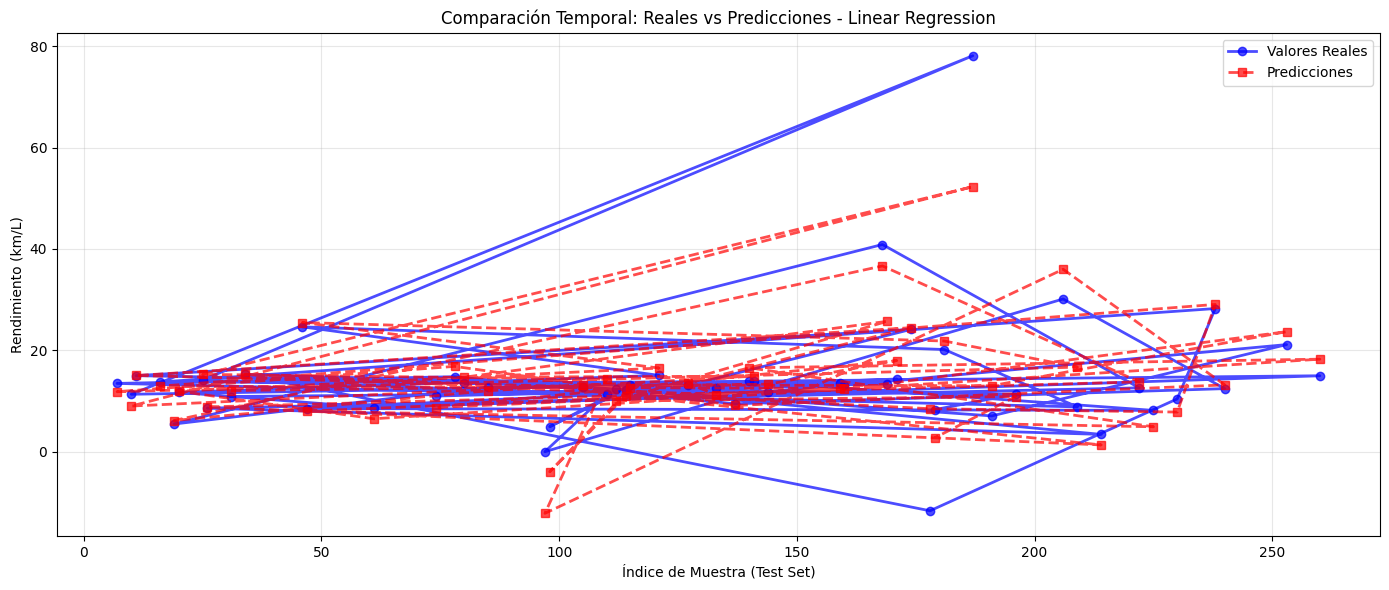


📊 ANÁLISIS DETALLADO DEL MEJOR MODELO:
   Modelo: Linear Regression
   R² Score: 0.7519
   MAE: 3.1582 km/L
   RMSE: 5.7485 km/L
   Error medio: -0.0214 km/L
   Desviación estándar de residuos: 5.8035 km/L

🎯 PRECISIÓN:
   34.0% de predicciones tienen error ≤ 1.0 km/L

✅ Visualización de predicciones completada


In [ ]:
# ==========================================
# VISUALIZACIÓN DE PREDICCIONES
# ==========================================

print("\n📈 VISUALIZACIÓN DE PREDICCIONES")
print("="*70)

# Obtener predicciones del mejor modelo
y_pred_mejor = resultados[mejor_modelo_nombre]['predicciones']

# ===== GRÁFICO 1: Predicciones vs Valores Reales =====
plt.figure(figsize=(16, 5))

# Subplot 1: Scatter plot
plt.subplot(1, 3, 1)
plt.scatter(y_test, y_pred_mejor, alpha=0.6, edgecolors='black', s=80)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         'r--', lw=2, label='Predicción perfecta')
plt.xlabel('Rendimiento Real (km/L)')
plt.ylabel('Rendimiento Predicho (km/L)')
plt.title(f'Predicciones vs Valores Reales\n{mejor_modelo_nombre}')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: Residuos (errores)
residuos = y_test - y_pred_mejor
plt.subplot(1, 3, 2)
plt.scatter(y_pred_mejor, residuos, alpha=0.6, edgecolors='black', s=80, color='orange')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2)
plt.xlabel('Rendimiento Predicho (km/L)')
plt.ylabel('Residuo (Real - Predicho)')
plt.title('Análisis de Residuos')
plt.grid(True, alpha=0.3)

# Subplot 3: Distribución de residuos
plt.subplot(1, 3, 3)
plt.hist(residuos, bins=20, edgecolor='black', alpha=0.7, color='green')
plt.axvline(x=0, color='red', linestyle='--', linewidth=2, label='Residuo = 0')
plt.xlabel('Residuo (km/L)')
plt.ylabel('Frecuencia')
plt.title('Distribución de Residuos')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ===== GRÁFICO 2: Serie temporal de predicciones =====
plt.figure(figsize=(14, 6))

# Crear índice temporal para el test set
indices_test = y_test.index

plt.plot(indices_test, y_test.values, 'o-', label='Valores Reales',
         linewidth=2, markersize=6, alpha=0.7, color='blue')
plt.plot(indices_test, y_pred_mejor, 's--', label='Predicciones',
         linewidth=2, markersize=6, alpha=0.7, color='red')
plt.xlabel('Índice de Muestra (Test Set)')
plt.ylabel('Rendimiento (km/L)')
plt.title(f'Comparación Temporal: Reales vs Predicciones - {mejor_modelo_nombre}')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ===== MÉTRICAS ADICIONALES =====
print(f"\n📊 ANÁLISIS DETALLADO DEL MEJOR MODELO:")
print(f"   Modelo: {mejor_modelo_nombre}")
print(f"   R² Score: {resultados[mejor_modelo_nombre]['r2']:.4f}")
print(f"   MAE: {resultados[mejor_modelo_nombre]['mae']:.4f} km/L")
print(f"   RMSE: {resultados[mejor_modelo_nombre]['rmse']:.4f} km/L")
print(f"   Error medio: {residuos.mean():.4f} km/L")
print(f"   Desviación estándar de residuos: {residuos.std():.4f} km/L")

# Porcentaje de predicciones dentro de cierto margen de error
tolerancia = 1.0  # km/L
dentro_tolerancia = np.abs(residuos) <= tolerancia
porcentaje = (dentro_tolerancia.sum() / len(residuos)) * 100

print(f"\n🎯 PRECISIÓN:")
print(f"   {porcentaje:.1f}% de predicciones tienen error ≤ {tolerancia} km/L")

print(f"\n✅ Visualización de predicciones completada")



🔄 VALIDACIÓN CRUZADA (K-FOLD)
Realizando validación cruzada con 5 folds...

📊 Linear Regression:
   R² por fold: ['0.761', '0.625', '0.746', '0.705', '0.754']
   R² promedio: 0.718 (+/- 0.101)

📊 Random Forest:
   R² por fold: ['0.950', '0.934', '0.969', '0.711', '0.883']
   R² promedio: 0.889 (+/- 0.188)

📊 Gradient Boosting:
   R² por fold: ['0.853', '0.905', '0.957', '0.757', '0.956']
   R² promedio: 0.886 (+/- 0.149)



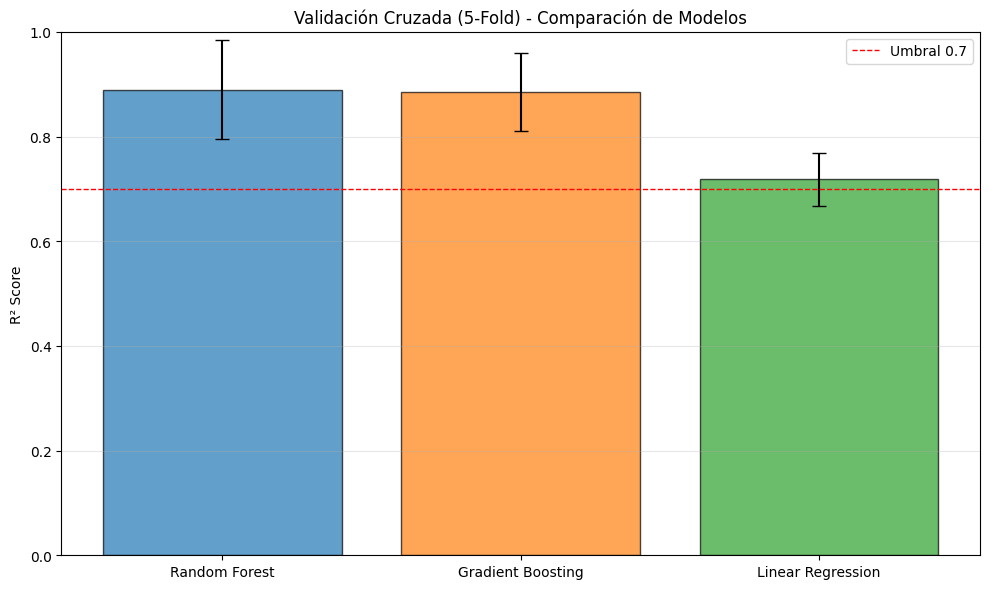

✅ Validación cruzada completada


In [ ]:
# ==========================================
# VALIDACIÓN CRUZADA (K-FOLD)
# ==========================================

print("\n🔄 VALIDACIÓN CRUZADA (K-FOLD)")
print("="*70)

# Realizar validación cruzada con 5 folds
k_folds = 5

print(f"Realizando validación cruzada con {k_folds} folds...\n")

for nombre_modelo in resultados.keys():
    modelo = resultados[nombre_modelo]['modelo']

    # Cross-validation scores
    cv_scores = cross_val_score(
        modelo, X, y,
        cv=k_folds,
        scoring='r2',
        n_jobs=-1
    )

    print(f"📊 {nombre_modelo}:")
    print(f"   R² por fold: {[f'{score:.3f}' for score in cv_scores]}")
    print(f"   R² promedio: {cv_scores.mean():.3f} (+/- {cv_scores.std() * 2:.3f})")
    print()

# Visualización de resultados de CV
cv_results = []
for nombre_modelo in resultados.keys():
    modelo = resultados[nombre_modelo]['modelo']
    cv_scores = cross_val_score(modelo, X, y, cv=k_folds, scoring='r2', n_jobs=-1)
    cv_results.append({
        'Modelo': nombre_modelo,
        'R² Promedio': cv_scores.mean(),
        'Desv. Estándar': cv_scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values('R² Promedio', ascending=False)

plt.figure(figsize=(10, 6))
plt.bar(cv_df['Modelo'], cv_df['R² Promedio'],
        yerr=cv_df['Desv. Estándar'],
        capsize=5, alpha=0.7, edgecolor='black',
        color=['#1f77b4', '#ff7f0e', '#2ca02c'])
plt.ylabel('R² Score')
plt.title(f'Validación Cruzada ({k_folds}-Fold) - Comparación de Modelos')
plt.ylim([0, 1])
plt.axhline(y=0.7, color='red', linestyle='--', linewidth=1, label='Umbral 0.7')
plt.legend()
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

print(f"✅ Validación cruzada completada")

In [ ]:
# ==========================================
# PREDICCIÓN EN NUEVOS DATOS
# ==========================================

print("\n🔮 EJEMPLO DE PREDICCIÓN EN NUEVOS DATOS")
print("="*70)

# Crear un ejemplo de nueva recarga para predecir
nueva_recarga = pd.DataFrame({
    'km_recorridos': [350],
    'Litros': [28],
    'Precio': [23.90],
    'dias_entre_recargas': [12],
    'mes': [3],
    'trimestre': [1],
    'dia_semana': [2],  # Miércoles
    'estacion_encoded': [0],  # Primavera (depende de tu encoding)
    'tipo_recarga_encoded': [1],  # Media
    'fin_semana_num': [0],
    'km_acumulados_norm': [0.5],
    'tendencia': [270],
    'precio_diff': [0.10],
    'rendimiento_ma5': [12.5]
})

# Realizar predicción
rendimiento_predicho = mejor_modelo.predict(nueva_recarga)[0]

print(f"📋 DATOS DE LA NUEVA RECARGA:")
print(f"   Km recorridos: {nueva_recarga['km_recorridos'][0]}")
print(f"   Litros: {nueva_recarga['Litros'][0]}")
print(f"   Precio: ${nueva_recarga['Precio'][0]}/L")
print(f"   Mes: {nueva_recarga['mes'][0]}")
print(f"   Fin de semana: {'Sí' if nueva_recarga['fin_semana_num'][0] else 'No'}")

print(f"\n🎯 PREDICCIÓN:")
print(f"   Rendimiento esperado: {rendimiento_predicho:.2f} km/L")

# Calcular rendimiento real para comparar
rendimiento_real = nueva_recarga['km_recorridos'][0] / nueva_recarga['Litros'][0]
print(f"   Rendimiento real calculado: {rendimiento_real:.2f} km/L")
print(f"   Diferencia: {abs(rendimiento_predicho - rendimiento_real):.2f} km/L")

print(f"\n✅ Predicción en nuevos datos completada")


🔮 EJEMPLO DE PREDICCIÓN EN NUEVOS DATOS
📋 DATOS DE LA NUEVA RECARGA:
   Km recorridos: 350
   Litros: 28
   Precio: $23.9/L
   Mes: 3
   Fin de semana: No

🎯 PREDICCIÓN:
   Rendimiento esperado: 17.07 km/L
   Rendimiento real calculado: 12.50 km/L
   Diferencia: 4.57 km/L

✅ Predicción en nuevos datos completada


In [ ]:
# ==========================================
# EXPORTAR EL MODELO
# ==========================================

print("\n💾 EXPORTAR MODELO Y OBJETOS")
print("="*70)

# Guardar el mejor modelo
nombre_archivo_modelo = f'modelo_{mejor_modelo_nombre.replace(" ", "_").lower()}.pkl'

with open(nombre_archivo_modelo, 'wb') as file:
    pickle.dump(mejor_modelo, file)

print(f"✅ Modelo guardado: {nombre_archivo_modelo}")

# Guardar el scaler (si lo usaste)
with open('scaler.pkl', 'wb') as file:
    pickle.dump(scaler, file)

print(f"✅ Scaler guardado: scaler.pkl")

# Guardar los nombres de features (importante para predicciones futuras)
with open('feature_names.pkl', 'wb') as file:
    pickle.dump(feature_candidates, file)

print(f"✅ Feature names guardados: feature_names.pkl")

# Guardar los encoders (si los usaste)
encoders = {
    'estacion': le_estacion,
    'tipo_recarga': le_tipo_recarga
}

with open('encoders.pkl', 'wb') as file:
    pickle.dump(encoders, file)

print(f"✅ Encoders guardados: encoders.pkl")

# Descargar archivos
from google.colab import files

files.download(nombre_archivo_modelo)
files.download('scaler.pkl')
files.download('feature_names.pkl')
files.download('encoders.pkl')

print(f"\n✅ Archivos descargados y listos para producción")


💾 EXPORTAR MODELO Y OBJETOS
✅ Modelo guardado: modelo_linear_regression.pkl
✅ Scaler guardado: scaler.pkl
✅ Feature names guardados: feature_names.pkl
✅ Encoders guardados: encoders.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


✅ Archivos descargados y listos para producción


In [ ]:
# ==========================================
# RESUMEN EJECUTIVO
# ==========================================

print("\n" + "="*70)
print("📊 RESUMEN EJECUTIVO - MODELO DE PREDICCIÓN DE RENDIMIENTO")
print("="*70)

print(f"\n🎯 OBJETIVO:")
print(f"   Predecir el rendimiento del vehículo (km/L) basado en")
print(f"   variables contextuales y de uso.")

print(f"\n📊 DATOS:")
print(f"   Total de registros: {len(df_clean)}")
print(f"   Features utilizadas: {len(feature_candidates)}")
print(f"   Training set: {len(X_train)} ({len(X_train)/len(X)*100:.0f}%)")
print(f"   Test set: {len(X_test)} ({len(X_test)/len(X)*100:.0f}%)")

print(f"\n🤖 MODELOS EVALUADOS:")
for i, (nombre, res) in enumerate(resultados.items(), 1):
    print(f"   {i}. {nombre}")
    print(f"      - R²: {res['r2']:.3f}")
    print(f"      - MAE: {res['mae']:.3f} km/L")
    print(f"      - RMSE: {res['rmse']:.3f} km/L")

print(f"\n🏆 MEJOR MODELO: {mejor_modelo_nombre}")
print(f"   - R² Score: {resultados[mejor_modelo_nombre]['r2']:.3f}")
print(f"   - MAE: {resultados[mejor_modelo_nombre]['mae']:.3f} km/L")
print(f"   - RMSE: {resultados[mejor_modelo_nombre]['rmse']:.3f} km/L")
print(f"   - {porcentaje:.1f}% de predicciones con error ≤ {tolerancia} km/L")

if mejor_modelo_nombre in ['Random Forest', 'Gradient Boosting']:
    print(f"\n🔍 TOP 5 FEATURES MÁS IMPORTANTES:")
    for i, row in feature_importance_df.head(5).iterrows():
        print(f"   {i+1}. {row['Feature']}: {row['Importance']:.3f}")

print(f"\n💼 APLICACIONES DE NEGOCIO:")
print(f"   • Mantenimiento predictivo de vehículos")
print(f"   • Optimización de rutas y hábitos de conducción")
print(f"   • Detección temprana de problemas mecánicos")
print(f"   • Planificación de presupuesto de combustible")
print(f"   • Escalable a flotas vehiculares (sector público/privado)")

print(f"\n📁 ENTREGABLES:")
print(f"   ✅ Modelo entrenado ({nombre_archivo_modelo})")
print(f"   ✅ Scaler (scaler.pkl)")
print(f"   ✅ Feature names (feature_names.pkl)")
print(f"   ✅ Encoders (encoders.pkl)")
print(f"   ✅ Notebook documentado")

print(f"\n✅ PROYECTO DE MACHINE LEARNING COMPLETADO")
print("="*70)


📊 RESUMEN EJECUTIVO - MODELO DE PREDICCIÓN DE RENDIMIENTO

🎯 OBJETIVO:
   Predecir el rendimiento del vehículo (km/L) basado en
   variables contextuales y de uso.

📊 DATOS:
   Total de registros: 261
   Features utilizadas: 14
   Training set: 208 (80%)
   Test set: 53 (20%)

🤖 MODELOS EVALUADOS:
   1. Linear Regression
      - R²: 0.752
      - MAE: 3.158 km/L
      - RMSE: 5.749 km/L
   2. Random Forest
      - R²: 0.668
      - MAE: 2.392 km/L
      - RMSE: 6.645 km/L
   3. Gradient Boosting
      - R²: 0.737
      - MAE: 2.034 km/L
      - RMSE: 5.915 km/L

🏆 MEJOR MODELO: Linear Regression
   - R² Score: 0.752
   - MAE: 3.158 km/L
   - RMSE: 5.749 km/L
   - 34.0% de predicciones con error ≤ 1.0 km/L

💼 APLICACIONES DE NEGOCIO:
   • Mantenimiento predictivo de vehículos
   • Optimización de rutas y hábitos de conducción
   • Detección temprana de problemas mecánicos
   • Planificación de presupuesto de combustible
   • Escalable a flotas vehiculares (sector público/privado)

📁 EN